## 概要

解説記事「[量子アニーリングを活用した非負二値行列因子分解による画像分類](https://qard.is.tohoku.ac.jp/T-Wave/2025/08/28/%e9%87%8f%e5%ad%90%e3%82%a2%e3%83%8b%e3%83%bc%e3%83%aa%e3%83%b3%e3%82%b0%e3%82%92%e6%b4%bb%e7%94%a8%e3%81%97%e3%81%9f%e9%9d%9e%e8%b2%a0%e4%ba%8c%e5%80%a4%e8%a1%8c%e5%88%97%e5%9b%a0%e5%ad%90%e5%88%86/)」では、非負二値行列因子分解を応用した多クラス画像分類モデルを提案し, 手書き数字画像を分類するという問題に対して提案モデルと全結合ニューラルネットワークでその性能を比較する論文を紹介しました。本記事では、そのアルゴリズムを実装し、元論文の再現実験を行います。

## 文献情報

* タイトル : Nonnegative/Binary matrix factorization for image classification using quantum annealing
* 著者 : Hinako Asaoka & Kazue Kudo
* 書誌情報 :
https://doi.org/10.1038/s41598-023-43729-z

## 手法

元論文で提案された手法である非負二値行列因子分解（NBMF）と実験で比較する際に用いる手法である全結合ニューラルネットワーク（FCNN）について簡単に振り返ります（詳細は[解説記事](https://qard.is.tohoku.ac.jp/T-Wave/2025/08/28/%e9%87%8f%e5%ad%90%e3%82%a2%e3%83%8b%e3%83%bc%e3%83%aa%e3%83%b3%e3%82%b0%e3%82%92%e6%b4%bb%e7%94%a8%e3%81%97%e3%81%9f%e9%9d%9e%e8%b2%a0%e4%ba%8c%e5%80%a4%e8%a1%8c%e5%88%97%e5%9b%a0%e5%ad%90%e5%88%86/)をご覧ください）。

### 非負二値行列因子分解（NBMF）

非負二値行列因子分解（NBMF）とは、ある行列$V$を基底行列$W$と係数行列$H$の積に分解する手法です（式(1)）。

$$V \approx WH \tag{1}$$

このとき、元の行列$V$は$n \times m$行列で、基底行列$W$は$n \times k$で成分が非負値の行列で係数行列$H$は$k \times m$で成分が二値の行列とします。

NBMFでは式(1)を満たすような$W$と$H$を求めるために、以下の式を用いてそれぞれ交互に更新します。

$$W := \arg\min_{X \in \mathbb{R}_{+n \times k} } \bigl( \| V - X H \|_F + \alpha \| X \|_F \bigl) \tag{2}$$
$$H := \arg\min_{X \in \{0,1\}^{k \times m}} \bigl\| V - W X \bigl\|_F \tag{3}$$

ここで、式(2)と式(3)に現れる$\| \cdot \|_F$はフロベニウスノルムと言い、行列の全成分の二乗和の平方根を表します。

元論文では、後述するRMSPropを用いて式(2)、量子アニーリングを用いて式(3)を解いて$W$と$H$を求めます。


### RMSPropで$W$を更新する

元論文で採用された手法であるRMSPropとは勾配降下法の一種で、勾配の二乗の移動平均$\boldsymbol{h}$に応じて学習率を自動で調整する手法です。勾配の二乗の移動平均$\boldsymbol{h}$は、ある時点$t$における勾配ベクトルを$\boldsymbol{g}$、以前の情報に対する重み定数$\beta$とすると、以下の式で表されます。

$$h_i^{t+1} = \beta h_i^t + \bigl( 1 - \beta \bigl) g_i^2 \tag{4}$$

また、式(2)において、$W$のある特定の行をベクトル$\boldsymbol{x}$の転置、$W$の行に対応する$V$の行をベクトル$\boldsymbol{v}$の転置として考えて、損失関数を以下のように定義します。

$$f_W(\boldsymbol{x}) = \| \boldsymbol{v} - H ^{\mathsf{T}} \boldsymbol{x}\|^2 + \alpha \| \boldsymbol{x} \|^2 \tag{5}$$

式(4)および式(5)を用いて変数$\boldsymbol{x}$の更新式を以下の通りとします。ただし、元論文において、実験に用いるデータセットはMNISTで、$W$に入る値を0以上1以下の実数とするため式(7)のような射影を考えています。また、$\eta$は学習率で、式(4)における勾配ベクトル$\boldsymbol{g}$は式(5)の損失関数の勾配$\nabla f_W(\boldsymbol{x})$としました。

$$\boldsymbol{x}^{t+1} = P \biggl[ \boldsymbol{x}^t - \eta \frac{1}{\sqrt{\boldsymbol{h}^t + \epsilon }} \nabla f_W(\boldsymbol{x}^t) \biggl] \tag{6}$$

$$P\left[x\right] =
\begin{cases}
0 \qquad x \leq 0 \\
x \qquad 0 < x < 1 \\
1 \qquad x \geq 1
\end{cases}
\tag{7}$$

以上のような、式(6)と式(7)を用いることでRMSPropによる$W$の更新が可能となります。



### 量子アニーリングで$H$を更新する

量子アニーリングとは組み合わせ最適化問題を解くための手法です。今回の問題において、式(3)は以下の式(8)ようなQUBO形式に変形できるため量子アニーリングマシンを用いて解くことができます。

$$ QUBO \bigl( \boldsymbol{q} \bigl) = \sum_{i \leq j} Q_{ij} q_i q_j \tag{8} $$

式(3)を式(8)の形となるように変形すると式(9)の目的関数が求められます。ただし、$H$のある特定の列をベクトル$\boldsymbol{q}$、$V$の特定の列を$\boldsymbol{v}$とします。

$$f_H \bigl( \boldsymbol{q} \bigl) = \sum_i \Bigl( \sum_r W_{ri} \bigl( W_{ri} - 2 v_r \bigr) _Bigr) q_i + 2 \sum_{i \leq j} \Bigl( \sum_r W_{ri} W_{rj} \Bigr) q_i q_j \tag{9}$$

このように目的関数を設定することで、$H$を求めるという問題を量子アニーリングを用いて解くことができます。


### 全結合ニューラルネットワーク（FCNN）

比較対象とするFCNNは、入力層・隠れ層・出力層がすべて全結合された構造のニューラルネットワークです。今回の実験では、隠れ層の活性化関数にReLU、出力層にソフトマックス関数を使用します。また、過学習防止のため隠れ層にはドロップアウト（率20%）を適用します。このドロップアウトとは、学習の各ステップにおいてランダムに20%のニューロンを無効化（出力を0に）する手法で、ネットワークが特定のニューロンに過度に依存することを防ぐ効果があります。

## NBMFを用いて画像分類問題を解く

ここでは、NBMFを用いて画像分類問題を解く方法を説明します。

実験に用いるデータセットはMNISTの手書き数字文字です。まず、学習として、この手書き数字文字画像$m$枚を入力として行列$V$に与えます。この時、画像1枚の画素数は$28 \times 28$の784であり、画像の0から9のクラス情報をOne-hotベクトルとして末尾に追加するため、行数$n$は$784 + 10$の794となります。

この入力行列$V$をNBMFを用いて分解して$W$と$H$を得ます。$W$と$H$の更新を1回ずつ行うことを1エポックの学習とします。この$W$に元の入力画像の特徴とその特徴から得られるクラスの情報が学習されているため、これを使ってテストデータを分類します。

$W$は$n \times k$行列で$k$は特徴数です。この$W$には特徴数$k$枚分の画像の特徴を表す$784 \times k$行列$W_1$と、その特徴を持つクラスの情報を表す$10 \times k$行列$W_2$が含まれます。

テストデータの分類ではまず、テストデータとなる画像$M$枚を入力行列$V_{test}$として、学習された$W$の$W_1$を用いて$H_{test}$を求めます。次に、$W_2$と$H_{test}$を乗算することで結果となる行列$U_{test}$が得られます。$V_{test}$の列に対応する$U_{test}$の列が予測されたクラス情報であり、この列に対してソフトマックス関数を適用して、最大の成分値を持つインデックスを予測されたクラスとします。

## 実装

### ライブラリをインポートする

実装に必要なライブラリをインポートします。

In [ ]:
!pip install dwave-neal
!pip install openjij

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
from time import time
import neal
from dimod import BinaryQuadraticModel
import torch
import torch.optim as optim
import torch.nn as nn
import inspect
import openjij as oj
from functools import total_ordering

### データの読み込み

本実験ではMNISTのデータセットを用いるので、その読み込みと訓練データとテストデータへの分割、またラベルをOne-hotエンコーディングし、画像データと結合して最終的な入力行列の作成を行います。このとき, 学習データはそれぞれのクラスを持つ画像の数が均等になるように作成します。

In [ ]:
def load_mnist_data(m_train=300, m_test=500, seed=0):
    """
    MNISTデータセットを読み込んで学習データと訓練データに分割する
    <入力>
    m_train：学習データ数
    m_test：テストデータ数
    seed：乱数シード
    <出力>
    X[train_idx]：学習データの入力行列
    y[train_idx]：学習データの正解ラベル
    X[test_idx]：テストデータの入力行列
    y[test_idx]：テストデータの正解ラベル
    """
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist['data'].astype(np.float32) / 255.0
    y = mnist['target'].astype(np.int64)

    rng = np.random.default_rng(seed)

    n_classes = 10
    per_class_train = m_train // n_classes

    train_idx_list = []

    for cls in range(n_classes):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        train_idx_list.append(cls_idx[:per_class_train])

    train_idx = np.concatenate(train_idx_list)
    rng.shuffle(train_idx)

    used = np.zeros(len(X), dtype=bool)
    used[train_idx] = True

    remaining_idx = np.where(~used)[0]
    rng.shuffle(remaining_idx)

    test_idx = remaining_idx[:m_test]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


### RMSPropによるWの更新処理の実装

まず、RMSPropによるWの更新をするための関数を作成します。式(6)の処理の実装ですが、この実装では、ベクトルごとに更新を行うのではなく、行列演算を用いて一括で更新処理を行っています。

In [ ]:
def update_W_rmsprop(V, W, H, S,
    lr=1e-2, alpha=1e-4, beta=0.99, eps=1e-7,
    tol=1, max_iter=40
):
    """
    RMSProp による W の更新を、勾配行列の最大値ノルムが一定値以下になるまで繰り返す
    前回に比べて勾配行列の最大値ノルムの誤差が tol 以下もしくは反復回数が max_iter に達したら終了
　　<入力>
    V：(n, m), 入力行列
    W：(n, k), 基底行列
    H：(k, m), 係数行列
    S：(n, k), 勾配の二乗の移動平均
    lr：float, 学習率
    alpha：float, 正則化係数
    beta：float, RMSPropの減衰率
    eps：float, ゼロ除算防止項
    tol：float, 勾配行列の最大値ノルムの閾値
    max_iter：int, 最大反復回数
    <出力>
    W：(n, k), 更新後の基底行列
    S：(n, k), 更新後の二乗平均
    t+1：int, 実際に行った反復回数
    """
    R = V - W @ H
    grad_prev = -(R @ H.T).astype(np.float32) + alpha * W
    grad_norm_prev = np.linalg.norm(grad_prev, np.inf)

    for t in range(max_iter):
        S[:] = beta * S + (1 - beta) * (grad_prev * grad_prev)
        W_new = W - lr * grad_prev / (np.sqrt(S + eps))
        W_new = np.clip(W_new, 0.0, 1.0)

        col_norm = np.linalg.norm(W_new, axis=0, keepdims=True) + 1e-6
        scale = np.minimum(1.0, 1.0 / col_norm).astype(np.float32)
        W_new = (W_new * scale).astype(np.float32)

        R = V - W_new @ H
        grad_new = -(R @ H.T).astype(np.float32) + alpha * W_new
        grad_norm_new = np.linalg.norm(grad_new, np.inf)

        grad_diff = np.abs(grad_norm_new - grad_norm_prev)

        # 調査用出力
        # print(f"iter {t:4d}: grad_norm={grad_norm_new:.6f}, ratio={ratio:.6f}")

        if  np.max(grad_diff) < tol:
            break

        W = W_new
        grad_prev = grad_new
        grad_norm_prev = grad_norm_new

    return W, S, t + 1

### 量子アニーリングによるHの更新処理の実装

次に量子アニーリングを用いたHの更新の処理を実装します。式(9)の実装と、量子アニーリング処理を行います。ただし、実験ではD-Wave NealあるいはOpneJijのSAサンプラーを使用します。
サンプラーへの入力はdict形式が求められるため、まず、線形項と上三角行列が与えられたときにQUBOのdictとして返す関数を作成します。

In [ ]:
def qubo_matrix_to_dict(b, Q):
    """
　　線形項と上三角行列から QUBO の辞書を返す
    <入力>
    b：(k,), QUBO の線形項
    Q：(k,k), 上三角成分を持つ QUBO 行列
    <出力>
    Q_dict：{(i,j): bias}, QUBO 行列の辞書
    """
    k = b.shape[0]
    Q_dict = {}
    for i in range(k):
        val = float(b[i])
        if val != 0.0:
            Q_dict[(i, i)] = val
    for i in range(k):
        for j in range(i+1, k):
            val = float(Q[i, j])
            if val != 0.0:
                Q_dict[(i, j)] = val
    return Q_dict

次にQUBOを作成するための計算を行う関数を作成します。

In [ ]:
def precompute_qubo_terms(W, v, l1=0.01):
    """
    式(9)に基づいて QUBO の係数を計算する
    f_H(q) = Σ_i [Σ_r W_ri(W_ri - 2v_r)] q_i  +  2 Σ_{i<j} [Σ_r W_ri W_rj] q_i q_j
    ここに、スパース化のための線形項 l1 * Σ q_i を追加して計算を行う。
    <入力>
    W  ：(m, k), 基底行列 (式中の W)
    v  ：(m,),   目標ベクトル (式中の v)
    l1 ：学習率 (式(9)には含まれないが、スパース性制約として線形項に加算)
    <出力>
    b  ：(k,),   線形項の係数 (式(9)の第1項 + l1)
    Q  ：(k,k),  二次項の係数 (式(9)の第2項, 上三角行列)
    """
    # W_ri * W_rj の和を計算 (G = W^T W)
    G = (W.T @ W).astype(np.float32)

    # v_r * W_ri の和を計算 (W^T v)
    wTv = (W.T @ v).astype(np.float32)

    # --- 線形項 (b) の計算 ---
    # 式(9) 第1項: Σ_r W_ri(W_ri - 2v_r) = Σ W_ri^2 - 2 Σ W_ri v_r
    # Gの対角成分 (np.diag(G)) が Σ W_ri^2 に相当
    # 最後にスパース化項 l1 を加算
    b = np.diag(G) - 2.0 * wTv + l1

    # --- 二次項 (Q) の計算 ---
    # 式(9) 第2項: 2 * Σ_{i<j} (Σ_r W_ri W_rj) q_i q_j
    # G の非対角成分 (上三角部分) を取り出し、係数 2 を掛ける
    Q = np.triu(G, 1).astype(np.float32) * 2.0

    return b, Q

作成されたQUBO行列を基にSAサンプラーに入力して解いてコスト関数値が最も低くなるようなQUBOとその時のエネルギーを返す関数を作成します。

In [ ]:
def simulated_annealing_qubo(b, Q, num_reads=50, seed=None, sampler=None):
    """
    Simulated Annealing サンプラーを使って QUBO を解く
    <入力>
    b：(k,) QUBO の線形項
    Q：(k,k) 上三角 QUBO 行列
    num_reads：サンプラーの num_reads
    seed：乱数シード
    sampler：既に作成済みの sampler
    <出力>
    best_q (numpy uint8 array)：得られた最適解ベクトル q
    best_energy (float)：最適解のエネルギー
    elapsed_time (float)：サンプリングに要した時間（秒）
    """
    Q_dict = qubo_matrix_to_dict(b, Q)
    sampler_name = sampler.__class__.__module__

    if "dwave" in sampler_name.lower():
        t0 = time()
        sampleset = sampler.sample_qubo(Q_dict)
        t1 = time()
        elapsed_time = t1 - t0
        first = sampleset.first
        sample = first.sample
        k = b.shape[0]
        q_best = np.zeros(k, dtype=np.uint8)
        for i in range(k):
            q_best[i] = int(sample.get(i, 0))
        best_energy = float(first.energy)

        return q_best, best_energy, elapsed_time

    elif "openjij" in sampler_name.lower():
        best_sample = None
        best_energy = float('inf')
        t0 = time()
        response = sampler.sample_qubo(Q_dict)
        t1 = time()
        elapsed_time = t1 - t0
        record = response.record[0]
        q = np.array(record.sample, dtype=np.uint8)
        e = float(record.energy)
        if e < best_energy:
            best_energy = e
            best_sample = q
        q_best = best_sample
        return q_best, best_energy, elapsed_time
    else:
        raise ValueError(f"Unknown sampler: {sampler_name}")

最後に、上記で作成した関数を用いてHを更新する関数を作成します。

In [ ]:
def update_H_by_SA_qubo(V, W, H,l1=0.01,rng=None, num_reads=50, sampler=None):
    """
    SA を用いて H を更新する
    <入力>
    V：(n,m), 目的とする行列
    W：(n,k), 基底行列
    H：(k,m), 係数行列
    l1：float, 正則化係数
    rng： numpy.random.Generator, 乱数生成器
    num_reads：int, サンプラーの num_reads
    sampler：既に作成済みの sampler
    <出力>
    H：(k,m), 更新後の係数行列
    total_elapsed_time：(float), 更新にかかった時間（秒）
    """
    if rng is None:
        rng = np.random.default_rng()
    n, m = V.shape
    k = W.shape[1]
    total_elapsed_time = 0

    if sampler is None:
        sampler = neal.SimulatedAnnealingSampler()

    for j in range(m):
        v = V[:, j]
        b, Q = precompute_qubo_terms(W, v, l1=l1)
        init_q = H[:, j].astype(np.uint8)

        seed = int(rng.integers(0, 2**31-1))
        q_opt, _, elapsed_time = simulated_annealing_qubo(
            b=b, Q=Q,
            num_reads=num_reads, seed=seed, sampler=sampler
        )

        H[:, j] = q_opt
        total_elapsed_time += elapsed_time
    return H, total_elapsed_time

### NBMFによる学習と予測

まず、得られた結果に適用するためのソフトマックス関数の作成を行います。

In [ ]:
def softmax(U, axis=0):
    axis = 0 if U.shape[0] == 10 else 1
    U = U - U.max(axis=axis, keepdims=True)
    ex = np.exp(U)
    return ex / ex.sum(axis=axis, keepdims=True)

以下がNBMFによる学習を1回分行うためのコードです。
NBMFの流れは以下に示すとおりです。


1.   $W$と$H$の初期化（$W$は0以上1未満の一様分布で$H$は\{0,1\}でランダム）
2.   $W$を射影RMSPropで更新
3.   $H$を量子アニーリングで更新
4.   2で更新した$W$を用いてテストデータ分類のための$H_{test}$作成
5.   得られた$H_{test}$を用いてテストデータを分類して精度と交差エントロピー誤差を評価
6.   指定されたepochs数分終わるまで2に戻ってループ



In [ ]:
def train_nbmf_once(X_train, y_train, X_test, y_test,
                    k=40, epochs=10, alpha=1e-4, lr_W=1e-2, g=9.0, l1=0.05, seed=0,
                    num_reads=50, verbose=False, sampler=None):
    """
    NBMF の学習を1回分実行する
    <入力>
    X_train：(m_train, n_features)
    y_train：(m_train,)
    X_test：(m_test, n_features)
    y_test：(m_test,)
    k：特徴数
    alpha, lr_W：W の正則化係数と学習率
    g：ラベルにかかる係数
    l1：H の QUBO における正則化係数
    sampler：SA サンプラー
    <出力>
    test_acc_list：(epochs,), エポックごとの精度
    test_ce_list：(epochs,), エポックごとの交差エントロピー誤差
    W：(n,k), 更新後の基底行列
    H：(k,m), 更新後の係数行列
    """
    rng = check_random_state(seed)

    # 学習データの整形
    n_img = X_train.shape[1]
    n_classes = 10
    m_train = X_train.shape[0]
    m_test = X_test.shape[0]

    # one-hot 行列 (n_classes, m)
    Y_train = np.eye(n_classes, dtype=np.float32)[y_train].T
    Y_test = np.eye(n_classes, dtype=np.float32)[y_test].T

    V_train = np.vstack([
        X_train.T.astype(np.float32),
        (g * Y_train).astype(np.float32)
    ])


    V_test_img = X_test.T.astype(np.float32)
    n_total = V_train.shape[0]

    # 初期値
    W = np.clip(rng.rand(n_total, k).astype(np.float32), 0.0, 1.0)
    H = rng.randint(0, 2, size=(k, m_train)).astype(np.uint8)

    # RMSProp に用いる勾配の初期化
    S = np.zeros_like(W, dtype=np.float32)

    test_acc_list = []
    test_ce_list = []

    best_loss = np.inf
    no_improve = 0
    n_iter = 0

    for ep in range(1, epochs + 1):
        t0 = time()

        # W 更新 (Projected RMSProp)
        W, S, n_iter = update_W_rmsprop(V_train, W, H.astype(np.float32), S, lr=lr_W, alpha=alpha)

        elapsed1 = time() - t0

        # H 更新（SA）
        H, H_elapsed_time = update_H_by_SA_qubo(
            V_train, W, H,
            l1=l1,
            rng=np.random.default_rng(seed + ep),
            num_reads=num_reads,
            sampler=sampler
        )

        # 3) テストで評価（この段階の W を使って SA により H_test を求める）
        k_curr = W.shape[1]
        H_test = np.zeros((k_curr, m_test), dtype=np.uint8)
        rng_test = np.random.default_rng(seed + ep + 1000)
        total_test_elapsed_time = 0
        for j in range(m_test):
            v = V_test_img[:, j]
            b, Q = precompute_qubo_terms(W[:n_img, :], v.astype(np.float32), l1=l1)
            init_q = rng_test.integers(0, 2, size=k_curr, dtype=np.uint8)
            q_opt, _, test_elapsed_time = simulated_annealing_qubo(
                b, Q,
                num_reads=num_reads,
                seed=int(rng_test.integers(0, 2**31-1)),
                sampler=sampler
            )
            H_test[:, j] = q_opt
            total_test_elapsed_time += test_elapsed_time

        # 出力（分類器部）
        W2 = W[n_img:, :]
        U_test = (W2 @ H_test.astype(np.float32)).astype(np.float32)
        P = softmax(U_test, axis=0)
        y_pred = P.argmax(axis=0)
        acc = accuracy_score(y_test, y_pred)
        ce = log_loss(y_test, P.T, labels=np.arange(n_classes))

        test_acc_list.append(acc)
        test_ce_list.append(ce)

        frob = np.linalg.norm((V_train - W @ H.astype(np.float32)), 'fro')

        print(f"[Epoch {ep:02d}] TestAcc={acc*100:.2f}%  CE={ce:.4f}") #W_num={n_iter} W-elapsed={elapsed1:.1f}s H-elapsed={H_elapsed_time:.1f}s test-elapsed={total_test_elapsed_time:.1f}s")

    return np.array(test_acc_list), np.array(test_ce_list), W, H, y_pred, H_test

### FCNNの実装

実験でNBMFと比較するためFCNNによる実装を行います。

In [ ]:
class FCNN(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=40, num_classes=10, dropout_rate=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
def train_fcnn_once(X_train, y_train, X_test, y_test,
                    hidden_dim=40, lr=0.001, epochs=10, batch_size=32, seed=0):
    """
    FCNN による学習を1回分行う
    <入力>
    X_train：(m_train, n_features)
    y_train：(m_train,)
    X_test：(m_test, n_features)
    y_test：(m_test,)
    hidden_dim：隠れ層の次元数
    lr：学習率
    epochs：エポック数
    batch_size：バッチサイズ
    seed：乱数シード
    <出力>
    test_acc_list：(epochs,), エポックごとの精度
    test_ce_list：(epochs,), エポックごとの交差エントロピー誤差
    """
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_t = torch.from_numpy(X_train).to(device)
    y_train_t = torch.from_numpy(y_train).to(device)
    X_test_t = torch.from_numpy(X_test).to(device)

    model = FCNN(hidden_dim=hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    test_acc_list = []
    test_ce_list = []

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train_t))
        total_loss = 0.0

        for i in range(0, len(X_train_t), batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # テスト評価
        model.eval()
        with torch.no_grad():
            logits_test = model(X_test_t)
            y_pred = logits_test.argmax(dim=1).cpu().numpy()
            probs = torch.softmax(logits_test, dim=1).cpu().numpy()
            acc = accuracy_score(y_test, y_pred)
            ce = log_loss(y_test, probs, labels=np.arange(10))
        test_acc_list.append(acc)
        test_ce_list.append(ce)

    return np.array(test_acc_list), np.array(test_ce_list)

### 結果を可視化するための関数

以下では学習データ数、特徴数、エポック数のそれぞれに対する精度と交差エントロピー誤差をグラフとして描画する関数を作成します。

In [ ]:
def plot_results_vs_train_size(train_sizes,
                               acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
                               acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf):
    """
    FCNN/NBMF の学習データに対する精度・交差エントロピー誤差を描画する
    <入力>
    train_sizes：学習データ数のリスト
    acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn：FCNNの精度・交差エントロピー誤差
    acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf：NBMFの精度・交差エントロピー誤差
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))

    # (a) 精度
    ax1.errorbar(train_sizes, acc_mean_fcnn*100, yerr=acc_std_fcnn*100,
                 fmt='o-', color='red', label='FCNN', capsize=3)
    ax1.errorbar(train_sizes, acc_mean_nbmf*100, yerr=acc_std_nbmf*100,
                 fmt='o-', color='blue', label='NBMF', capsize=3)
    ax1.set_xlabel("Training data size (m_train)")
    ax1.set_ylabel("Test Accuracy (%)")
    ax1.set_title("(a) Accuracy vs. training data size")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # (b) 交差エントロピー誤差
    ax2.errorbar(train_sizes, ce_mean_fcnn, yerr=ce_std_fcnn,
                 fmt='o-', color='red', label='FCNN', capsize=3)
    ax2.errorbar(train_sizes, ce_mean_nbmf, yerr=ce_std_nbmf,
                 fmt='o-', color='blue', label='NBMF', capsize=3)
    ax2.set_xlabel("Training data size (m_train)")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.set_title("(b) Cross-entropy vs. training data size")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_results_vs_k(k_list,
                      acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
                      acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf):
    """
    FCNN/NBMF の特徴数に対する精度・交差エントロピー誤差を描画する
    <入力>
    k_list：特徴数のリスト
    acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn：FCNNの精度・交差エントロピー誤差
    acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf：NBMFの精度・交差エントロピー誤差
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))

    # (a) 精度
    ax1.errorbar(k_list, acc_mean_fcnn*100, yerr=acc_std_fcnn*100,
                 fmt='o-', color='red', label='FCNN', capsize=3)
    ax1.errorbar(k_list, acc_mean_nbmf*100, yerr=acc_std_nbmf*100,
                 fmt='o-', color='blue', label='NBMF', capsize=3)
    ax1.set_xlabel("k (hidden_dim / basis size)")
    ax1.set_ylabel("Test Accuracy (%)")
    ax1.set_title("(a) Accuracy vs. k")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # (b) 交差エントロピー誤差
    ax2.errorbar(k_list, ce_mean_fcnn, yerr=ce_std_fcnn,
                 fmt='o-', color='red', label='FCNN', capsize=3)
    ax2.errorbar(k_list, ce_mean_nbmf, yerr=ce_std_nbmf,
                 fmt='o-', color='blue', label='NBMF', capsize=3)
    ax2.set_xlabel("k (hidden_dim / basis size)")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.set_title("(b) Cross-entropy vs. k")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_learning_curves(fcnn_epochs, nbmf_epochs, acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
                         acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf):
    """
    FCNN/NBMF のエポック数に対する精度・交差エントロピー誤差を描画する
    <入力>
    fcnn_epochs：FCNNのエポック数
    nbmf_epochs：NBMFのエポック数
    acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn：FCNNの精度・交差エントロピー誤差
    acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf：NBMFの精度・交差エントロピー誤差
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))
    x1 = np.arange(1, fcnn_epochs+1)
    x2 = np.arange(1, nbmf_epochs+1)

    # (a) 精度
    ax1.plot(x1, acc_mean_fcnn*100, label='FCNN', color='red')

    ax1.plot(x2, acc_mean_nbmf*100, label='NBMF', color='blue')

    ax1.set_xscale("log")
    ax1.set_xlabel("Epoch (log scale)")
    ax1.set_ylabel("Average Test Accuracy (%)")
    ax1.set_title("(a) Average test accuracy vs. epochs")
    ax1.legend()
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)

    # (b) 交差エントロピー誤差
    ax2.plot(x1, ce_mean_fcnn, label='FCNN', color='red')

    ax2.plot(x2, ce_mean_nbmf, label='NBMF', color='blue')

    ax2.set_xscale("log")
    ax2.set_xlabel("Epoch (log scale)")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.set_title("(b) Cross-entropy loss vs. epochs")
    ax2.legend()
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

## 実験

元論文での実験と同様に、本記事では学習データ、特徴数、エポック数をそれぞれ変化させた場合の精度と交差エントロピー誤差でNBMFとFCNNの比較実験を行います。

### 学習データ数に対する精度と交差エントロピー誤差でNBMFとFCNNの比較を行う実験

まず、学習データ数を50から350まで25ずつ変化させた場合の精度と交差エントロピー誤差について, NBMFとFCNNの性能を比較する実験を行います。各種パラメータは論文に基づいて以下のように設定します。

In [ ]:
# 共通パラメータ
epochs = 10
num_repeats = 3
m_test = 500
seed = 0
train_sizes = list(range(50, 351, 25))

# --- FCNNパラメータ ---
hidden_dim = 40
lr = 0.0002
batch_size = 32

# --- NBMFパラメータ ---
k = 40
g = 9.0
alpha = 1e-4
lr_W = 0.01
l1 = 0
# sampler = oj.SASampler()
sampler = neal.SimulatedAnnealingSampler()

In [ ]:
acc_mean_fcnn_list, acc_std_fcnn_list = [], []
ce_mean_fcnn_list, ce_std_fcnn_list = [], []
acc_mean_nbmf_list, acc_std_nbmf_list = [], []
ce_mean_nbmf_list, ce_std_nbmf_list = [], []

for m_train in train_sizes:
    print(f"\n--- m_train = {m_train} ---")

    # データ読み込み
    X_train, y_train, X_test, y_test = load_mnist_data(m_train, m_test, seed=seed)

    # ---- FCNN ----
    accs_fcnn, ces_fcnn = [], []
    for s in range(num_repeats):
        acc_fcnn, ce_fcnn = train_fcnn_once(
            X_train, y_train, X_test, y_test,
            hidden_dim=hidden_dim, lr=lr, epochs=epochs,
            batch_size=batch_size, seed=s
        )
        accs_fcnn.append(acc_fcnn[-1])
        ces_fcnn.append(ce_fcnn[-1])

    acc_mean_fcnn_list.append(np.mean(accs_fcnn))
    acc_std_fcnn_list.append(np.std(accs_fcnn))
    ce_mean_fcnn_list.append(np.mean(ces_fcnn))
    ce_std_fcnn_list.append(np.std(ces_fcnn))

    # ---- NBMF ----
    accs_nbmf, ces_nbmf = [], []
    for s in range(num_repeats):
        print(f"  --- NBMF 実験 {s+1}/3 ---")
        acc_nbmf, ce_nbmf, W_final, H_final, y_pred, H_test = train_nbmf_once(
            X_train, y_train, X_test, y_test,
            k=k, epochs=epochs, alpha=alpha, lr_W=lr_W, g=g,l1=l1,
            seed=s, num_reads=50, verbose=False, sampler=sampler
        )
        accs_nbmf.append(acc_nbmf[-1])
        ces_nbmf.append(ce_nbmf[-1])

    acc_mean_nbmf_list.append(np.mean(accs_nbmf))
    acc_std_nbmf_list.append(np.std(accs_nbmf))
    ce_mean_nbmf_list.append(np.mean(ces_nbmf))
    ce_std_nbmf_list.append(np.std(ces_nbmf))

acc_mean_fcnn = np.array(acc_mean_fcnn_list)
acc_std_fcnn = np.array(acc_std_fcnn_list)
ce_mean_fcnn = np.array(ce_mean_fcnn_list)
ce_std_fcnn = np.array(ce_std_fcnn_list)
acc_mean_nbmf = np.array(acc_mean_nbmf_list)
acc_std_nbmf = np.array(acc_std_nbmf_list)
ce_mean_nbmf = np.array(ce_mean_nbmf_list)
ce_std_nbmf = np.array(ce_std_nbmf_list)


--- m_train = 50 ---
  --- NBMF 実験 1/3 ---
[Epoch 01] TestAcc=30.60%  CE=2.1981
[Epoch 02] TestAcc=62.20%  CE=1.6639
[Epoch 03] TestAcc=63.80%  CE=1.5467
[Epoch 04] TestAcc=64.80%  CE=1.4787
[Epoch 05] TestAcc=65.40%  CE=1.4792
[Epoch 06] TestAcc=65.60%  CE=1.4804
[Epoch 07] TestAcc=65.60%  CE=1.4755
[Epoch 08] TestAcc=66.20%  CE=1.4775
[Epoch 09] TestAcc=64.80%  CE=1.4750
[Epoch 10] TestAcc=64.60%  CE=1.4787
  --- NBMF 実験 2/3 ---
[Epoch 01] TestAcc=35.60%  CE=2.1371
[Epoch 02] TestAcc=66.40%  CE=1.4351
[Epoch 03] TestAcc=67.40%  CE=1.4289
[Epoch 04] TestAcc=66.80%  CE=1.4095
[Epoch 05] TestAcc=67.20%  CE=1.4106
[Epoch 06] TestAcc=66.60%  CE=1.4138
[Epoch 07] TestAcc=67.80%  CE=1.4147
[Epoch 08] TestAcc=67.40%  CE=1.4090
[Epoch 09] TestAcc=66.80%  CE=1.4046
[Epoch 10] TestAcc=67.20%  CE=1.4052
  --- NBMF 実験 3/3 ---
[Epoch 01] TestAcc=36.80%  CE=2.1974
[Epoch 02] TestAcc=63.20%  CE=1.5463
[Epoch 03] TestAcc=62.40%  CE=1.5454
[Epoch 04] TestAcc=62.00%  CE=1.5447
[Epoch 05] TestAcc=62.40

結果を表示します。

In [ ]:
print("m_train |  FCNN_Acc(%)  NBMF_Acc(%)  |  FCNN_CE   NBMF_CE")
for m, af, an, cf, cn in zip(train_sizes, acc_mean_fcnn, acc_mean_nbmf, ce_mean_fcnn, ce_mean_nbmf):
    print(f"{m:6d} |   {af*100:7.2f}      {an*100:7.2f}   |  {cf:8.4f}  {cn:8.4f}")

m_train |  FCNN_Acc(%)  NBMF_Acc(%)  |  FCNN_CE   NBMF_CE
    50 |     27.20        64.20   |    2.2426    1.4770
    75 |     28.87        64.87   |    2.2279    1.3367
   100 |     33.87        63.33   |    2.1930    1.3802
   125 |     39.60        68.27   |    2.1622    1.3282
   150 |     47.53        68.67   |    2.1169    1.2775
   175 |     46.93        66.07   |    2.0992    1.3526
   200 |     52.60        68.53   |    2.0492    1.2657
   225 |     55.27        70.67   |    2.0309    1.2157
   250 |     62.13        71.80   |    1.9678    1.1786
   275 |     63.13        72.73   |    1.9374    1.1520
   300 |     65.47        72.40   |    1.8779    1.2167
   325 |     66.00        70.53   |    1.8833    1.2285
   350 |     67.80        69.67   |    1.8193    1.2463


結果をグラフで描画します。

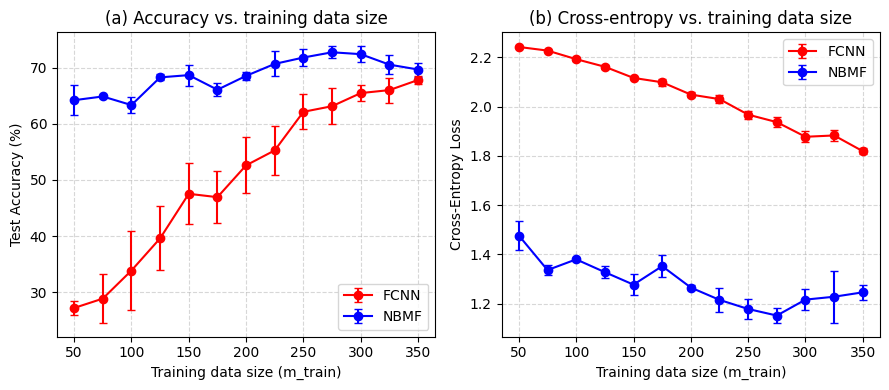

In [ ]:
plot_results_vs_train_size(train_sizes,
                           acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
                           acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf)

### 特徴数に対する精度と交差エントロピー誤差でNBMFとFCNNの比較を行う実験

次に、特徴数を10から100まで10ずつ変化させた場合の精度と交差エントロピー誤差について、NBMFとFCNNで比較する実験を行います。まずは、パラメータの設定です。

In [ ]:
# 共通パラメータ
epochs = 10
num_repeats = 3
m_train = 150
m_test = 500
seed = 0
k_list = list(range(10, 101, 10))

# --- FCNNパラメータ ---
lr = 0.0002
batch_size = 32

# --- NBMFパラメータ ---
g = 9.0
alpha = 1e-4
lr_W = 0.01
l1 = 0
# sampler = oj.SASampler()
sampler = neal.SimulatedAnnealingSampler()

次に学習データとテストデータの読み込みを行います。

In [ ]:
X_train, y_train, X_test, y_test = load_mnist_data(m_train, m_test, seed=seed)

それでは実験を行います。

In [ ]:
acc_mean_fcnn_list, acc_std_fcnn_list = [], []
ce_mean_fcnn_list, ce_std_fcnn_list = [], []
acc_mean_nbmf_list, acc_std_nbmf_list = [], []
ce_mean_nbmf_list, ce_std_nbmf_list = [], []

for k in k_list:
    print(f"\n--- k = {k} ---")

    # ---- FCNN ----
    accs_fcnn, ces_fcnn = [], []
    for s in range(num_repeats):
        acc_fcnn, ce_fcnn = train_fcnn_once(
            X_train, y_train, X_test, y_test,
            hidden_dim=k, lr=lr, epochs=epochs,
            batch_size=batch_size, seed=s
        )
        accs_fcnn.append(acc_fcnn[-1])
        ces_fcnn.append(ce_fcnn[-1])

    acc_mean_fcnn_list.append(np.mean(accs_fcnn))
    acc_std_fcnn_list.append(np.std(accs_fcnn))
    ce_mean_fcnn_list.append(np.mean(ces_fcnn))
    ce_std_fcnn_list.append(np.std(ces_fcnn))

    # ---- NBMF ----
    accs_nbmf, ces_nbmf = [], []
    for s in range(num_repeats):
        print(f"  --- NBMF 実験 {s+1}/3 ---")
        acc_nbmf, ce_nbmf, W_final, H_final, y_pred, H_test = train_nbmf_once(
            X_train, y_train, X_test, y_test,
            k=k, epochs=epochs, alpha=alpha, lr_W=lr_W, g=g,l1=l1,
            seed=s, num_reads=50, verbose=False, sampler=sampler
        )
        accs_nbmf.append(acc_nbmf[-1])
        ces_nbmf.append(ce_nbmf[-1])

    acc_mean_nbmf_list.append(np.mean(accs_nbmf))
    acc_std_nbmf_list.append(np.std(accs_nbmf))
    ce_mean_nbmf_list.append(np.mean(ces_nbmf))
    ce_std_nbmf_list.append(np.std(ces_nbmf))

# numpy配列化
acc_mean_fcnn = np.array(acc_mean_fcnn_list)
acc_std_fcnn = np.array(acc_std_fcnn_list)
ce_mean_fcnn = np.array(ce_mean_fcnn_list)
ce_std_fcnn = np.array(ce_std_fcnn_list)
acc_mean_nbmf = np.array(acc_mean_nbmf_list)
acc_std_nbmf = np.array(acc_std_nbmf_list)
ce_mean_nbmf = np.array(ce_mean_nbmf_list)
ce_std_nbmf = np.array(ce_std_nbmf_list)


--- k = 10 ---
  --- NBMF 実験 1/3 ---
[Epoch 01] TestAcc=18.80%  CE=2.2292
[Epoch 02] TestAcc=36.60%  CE=2.1295
[Epoch 03] TestAcc=36.80%  CE=2.1312
[Epoch 04] TestAcc=36.80%  CE=2.1273
[Epoch 05] TestAcc=38.00%  CE=2.1253
[Epoch 06] TestAcc=37.80%  CE=2.1286
[Epoch 07] TestAcc=37.40%  CE=2.1278
[Epoch 08] TestAcc=36.60%  CE=2.1325
[Epoch 09] TestAcc=36.80%  CE=2.1285
[Epoch 10] TestAcc=38.00%  CE=2.1274
  --- NBMF 実験 2/3 ---
[Epoch 01] TestAcc=25.00%  CE=2.2475
[Epoch 02] TestAcc=41.20%  CE=2.1302
[Epoch 03] TestAcc=41.40%  CE=2.1262
[Epoch 04] TestAcc=42.00%  CE=2.1261
[Epoch 05] TestAcc=40.20%  CE=2.1270
[Epoch 06] TestAcc=41.40%  CE=2.1275
[Epoch 07] TestAcc=42.20%  CE=2.1253
[Epoch 08] TestAcc=41.80%  CE=2.1278
[Epoch 09] TestAcc=42.80%  CE=2.1217
[Epoch 10] TestAcc=39.80%  CE=2.1332
  --- NBMF 実験 3/3 ---
[Epoch 01] TestAcc=27.20%  CE=2.2351
[Epoch 02] TestAcc=35.60%  CE=2.1493
[Epoch 03] TestAcc=35.40%  CE=2.1403
[Epoch 04] TestAcc=35.60%  CE=2.1329
[Epoch 05] TestAcc=36.00%  CE=

結果を表示します。

In [ ]:
print("   k   |  FCNN_Acc(%)  NBMF_Acc(%)  |  FCNN_CE   NBMF_CE")
for k, af, an, cf, cn in zip(k_list, acc_mean_fcnn, acc_mean_nbmf, ce_mean_fcnn, ce_mean_nbmf):
    print(f"{k:5d} |   {af*100:7.2f}      {an*100:7.2f}   |  {cf:8.4f}  {cn:8.4f}")

   k   |  FCNN_Acc(%)  NBMF_Acc(%)  |  FCNN_CE   NBMF_CE
   10 |     21.20        37.67   |    2.2296    2.1300
   20 |     31.27        57.47   |    2.1923    1.7585
   30 |     44.67        67.60   |    2.1245    1.4256
   40 |     47.53        69.67   |    2.1169    1.2815
   50 |     48.20        67.80   |    2.0603    1.2813
   60 |     56.33        67.80   |    2.0662    1.1745
   70 |     59.60        70.27   |    2.0106    1.1215
   80 |     53.00        68.80   |    2.0119    1.1102
   90 |     62.60        70.07   |    1.9880    1.1139
  100 |     59.93        69.87   |    1.9878    1.0609


結果をグラフとして描画します。

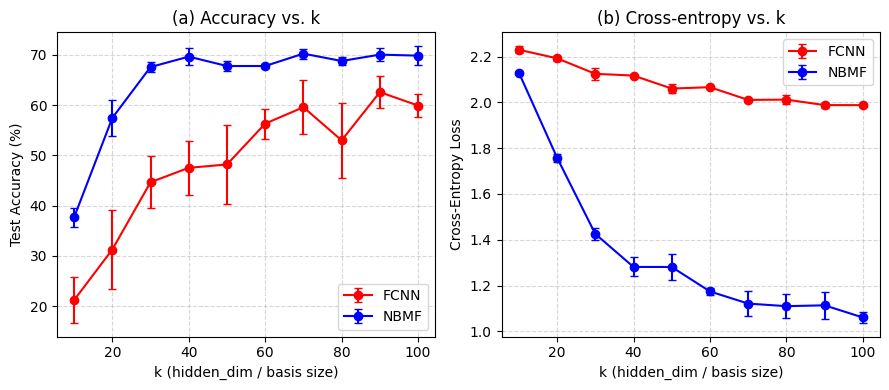

In [ ]:
plot_results_vs_k(k_list,
                  acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
                  acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf)

### エポック数に対する精度と交差エントロピー誤差でNBMFとFCNNの比較を行う実験

最後に、エポック数を100に設定し, 1エポックごとの精度と交差エントロピー誤差からNBMFとFCNNで比較する実験を行います。まずは、パラメータの設定です。

In [ ]:
m_train = 300
m_test = 500
num_repeats=3
seed = 0

# --- FCNNパラメータ ---
hidden_dim = 40
fcnn_epochs = 200
lr = 0.0002
batch_size = 32

# --- NBMFパラメータ ---
k = 40
nbmf_epochs = 100
num_reads=50
g = 9.0
alpha = 1e-4
lr_W = 0.01
l1 = 0
seed = 0
# sampler = neal.SimulatedAnnealingSampler()
sampler = oj.SASampler()

学習データとテストデータを読み込みます。

In [ ]:
X_train, y_train, X_test, y_test = load_mnist_data(m_train, m_test, seed=seed)

FCNNの実験を行います。

In [ ]:
# --- FCNN ---
accs_fcnn, ces_fcnn = [], []
acc_mean_fcnn, acc_std_fcnn = [], []
ce_mean_fcnn, ce_std_fcnn = [], []
for s in range(num_repeats):
    print(f"\n=== FCNN 実験 {s+1}/3 ===")
    acc_fcnn, ce_fcnn = train_fcnn_once(
        X_train, y_train, X_test, y_test,
        hidden_dim=hidden_dim, lr=lr, epochs=fcnn_epochs,
        batch_size=batch_size, seed=s
    )
    accs_fcnn.append(acc_fcnn)
    ces_fcnn.append(ce_fcnn)
accs_fcnn = np.array(accs_fcnn)
ces_fcnn = np.array(ces_fcnn)
acc_mean_fcnn, acc_std_fcnn = accs_fcnn.mean(axis=0), accs_fcnn.std(axis=0)
ce_mean_fcnn, ce_std_fcnn = ces_fcnn.mean(axis=0), ces_fcnn.std(axis=0)


=== FCNN 実験 1/3 ===

=== FCNN 実験 2/3 ===

=== FCNN 実験 3/3 ===


NBMFの実験を行います。

In [ ]:
# --- NBMF ---
accs_nbmf, ces_nbmf = [], []
acc_mean_nbmf, acc_std_nbmf = [], []
ce_mean_nbmf, ce_std_nbmf = [], []
for s in range(num_repeats):
    print(f"\n=== NBMF 実験 {s+1}/3 ===")
    acc_nbmf, ce_nbmf, W_final, H_final, y_pred, H_test = train_nbmf_once(
        X_train, y_train, X_test, y_test,
        k=k, epochs=nbmf_epochs, alpha=alpha, lr_W=lr_W, g=g, l1=l1,
        seed=s, num_reads=num_reads, verbose=True, sampler=sampler
    )
    L = len(acc_nbmf)
    if L < nbmf_epochs:
        pad_len = nbmf_epochs - L
        acc_nbmf = np.concatenate([acc_nbmf, np.full(pad_len, acc_nbmf[-1])])
        ce_nbmf = np.concatenate([ce_nbmf, np.full(pad_len, ce_nbmf[-1])])
    accs_nbmf.append(acc_nbmf[:nbmf_epochs])
    ces_nbmf.append(ce_nbmf[:nbmf_epochs])

accs_nbmf = np.array(accs_nbmf)
ces_nbmf = np.array(ces_nbmf)
acc_mean_nbmf, acc_std_nbmf = accs_nbmf.mean(axis=0), accs_nbmf.std(axis=0)
ce_mean_nbmf, ce_std_nbmf = ces_nbmf.mean(axis=0), ces_nbmf.std(axis=0)


=== NBMF 実験 1/3 ===
[Epoch 01] TestAcc=17.00%  CE=2.2679
[Epoch 02] TestAcc=62.80%  CE=1.6153
[Epoch 03] TestAcc=64.60%  CE=1.3973
[Epoch 04] TestAcc=66.40%  CE=1.2598
[Epoch 05] TestAcc=66.20%  CE=1.2397
[Epoch 06] TestAcc=66.60%  CE=1.2414
[Epoch 07] TestAcc=70.00%  CE=1.1960
[Epoch 08] TestAcc=69.20%  CE=1.2080
[Epoch 09] TestAcc=68.40%  CE=1.2084
[Epoch 10] TestAcc=69.00%  CE=1.2254
[Epoch 11] TestAcc=69.80%  CE=1.2148
[Epoch 12] TestAcc=71.40%  CE=1.2079
[Epoch 13] TestAcc=68.40%  CE=1.1918
[Epoch 14] TestAcc=69.20%  CE=1.2030
[Epoch 15] TestAcc=68.80%  CE=1.2162
[Epoch 16] TestAcc=67.40%  CE=1.2305
[Epoch 17] TestAcc=69.60%  CE=1.2097
[Epoch 18] TestAcc=68.40%  CE=1.2100
[Epoch 19] TestAcc=68.40%  CE=1.1948
[Epoch 20] TestAcc=71.60%  CE=1.1994
[Epoch 21] TestAcc=70.00%  CE=1.2046
[Epoch 22] TestAcc=69.80%  CE=1.2070
[Epoch 23] TestAcc=68.80%  CE=1.2195
[Epoch 24] TestAcc=69.00%  CE=1.2194
[Epoch 25] TestAcc=71.00%  CE=1.2088
[Epoch 26] TestAcc=67.20%  CE=1.2277
[Epoch 27] TestAc

FCNNとNBMFそれぞれの平均精度と交差エントロピー誤差を表示します。

In [ ]:
print("\n平均精度（FCNN）:", acc_mean_fcnn[-1]*100, "%")
print("平均交差エントロピー誤差（FCNN）:", ce_mean_fcnn[-1])
print("平均精度（NBMF）:", acc_mean_nbmf[-1]*100, "%")
print("平均交差エントロピー誤差（NBMF）:", ce_mean_nbmf[-1])


平均精度（FCNN）: 84.39999999999999 %
平均交差エントロピー誤差（FCNN）: 0.5280500643255045
平均精度（NBMF）: 70.73333333333332 %
平均交差エントロピー誤差（NBMF）: 1.1785668295091172


学習曲線を描画します。

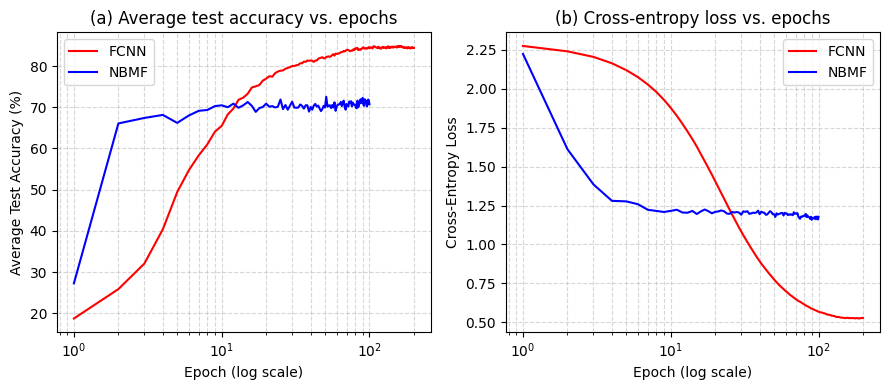

In [ ]:
plot_learning_curves(
    fcnn_epochs, nbmf_epochs,
    acc_mean_fcnn, acc_std_fcnn, ce_mean_fcnn, ce_std_fcnn,
    acc_mean_nbmf, acc_std_nbmf, ce_mean_nbmf, ce_std_nbmf
)

### $W$の中身の可視化

エポック数に対する精度と交差エントロピー誤差を比較した実験に対して、$W$の中身と結果を可視化してみます。
以下では、まず$W$の中身の画像を表す部分を表示する関数、その画像のクラス情報を表すヒストグラムを描画する関数、その画像がそれぞれの数字を再構成する際に何回用いられたかを表すヒストグラムを描画する関数を作成します。


In [ ]:
def show_W_column(W1, idx):
    """
    W1（画像部分の基底行列）の特定の列を画像として表示する
    <入力>
    W1：(784, k), 画像成分の基底行列
    idx：(int), 表示する基底のインデックス
    <出力>
    なし
    """
    img = W1[:, idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

def compute_usage_histogram(H, y_train, k):
    """
    各基底ベクトルがどのクラス（数字ラベル）のデータ再構成に使用されたかを集計する
    <入力>
    H：(k, n_samples), 係数行列
    y_train：(n_samples,), 教師データの正解ラベル
    k：(int), 基底ベクトルの数
    <出力>
    usage：(10, k), クラスごとの基底使用回数を格納した行列
    """
    usage = np.zeros((10, k), dtype=int)

    for img_idx in range(H.shape[1]):
        active = H[:, img_idx] > 0
        label = y_train[img_idx]
        usage[label, active] += 1

    return usage

def plot_usage_histogram(usage, idx):
    """
    特定の基底が各クラス（0-9）でどれくらいの頻度で使用されたかを棒グラフで表示する
    <入力>
    usage：(10, k), compute_usage_histogramで計算された使用頻度行列
    idx：(int), 表示対象の基底インデックス
    <出力>
    なし
    """
    plt.bar(np.arange(10), usage[:, idx])
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.title(f"Usage histogram for W column {idx}")

def plot_W2_bar(W2, idx):
    """
    ラベル情報部分（W2）の重みの棒グラフを表示する
    <入力>
    W2：(10, k), ラベル成分の基底行列
    idx：(int), 表示対象の基底インデックス
    <出力>
    なし
    """
    plt.bar(np.arange(10), W2[:, idx])
    plt.xlabel("Label index")
    plt.ylabel("Value")
    plt.title(f"W2 contributions for column {idx}")

def plot_W_feature_analysis(W, H, y_train, idx):
    """
    特定の基底について、基底画像・クラス使用頻度・ラベル寄与（W2）をまとめて可視化する
    <入力>
    W：(794, k), 画像成分とラベル成分が結合された基底行列
    H：(k, n_samples), 係数行列
    y_train：(n_samples,), 教師データの正解ラベル
    idx：(int), 分析対象の基底インデックス
    <出力>
    なし
    """
    n_img = 784
    W1 = W[:n_img, :]
    W2 = W[n_img:, :]

    usage = compute_usage_histogram(H, y_train, W.shape[1])

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    axes[0].imshow(W1[:, idx].reshape(28, 28), cmap='gray')
    axes[0].set_title(f"W1 column {idx}")
    axes[0].axis('off')

    axes[1].bar(np.arange(10), usage[:, idx])
    axes[1].set_title("Usage bar graph")
    axes[1].set_xlabel("Label")

    axes[2].bar(np.arange(10), W2[:, idx])
    axes[2].set_title("W2 contribution")
    axes[2].set_xlabel("Label")

    plt.tight_layout()
    plt.show()

作成した関数を用いて$W_1$の特定の1列が表す画像とその列がそれぞれの数字を再構成するのに用いられた回数、および$W_2$の同じ列の情報を表す棒グラフを描画します。

=== W の基底可視化と使用頻度 ===


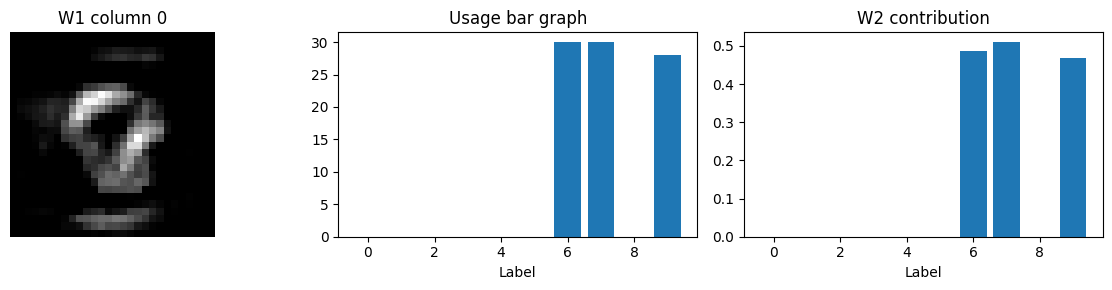

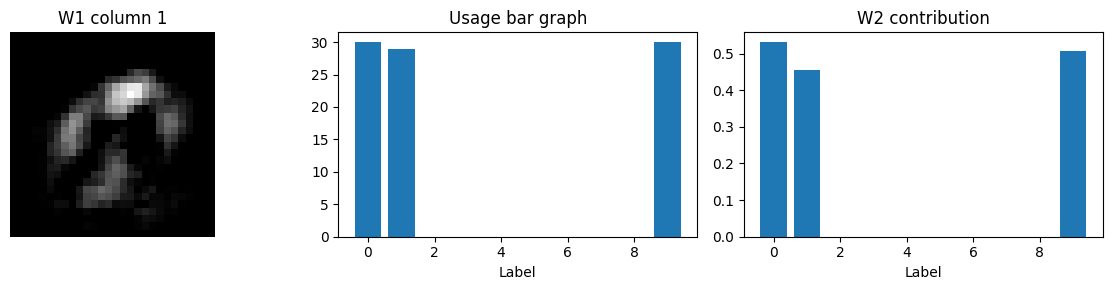

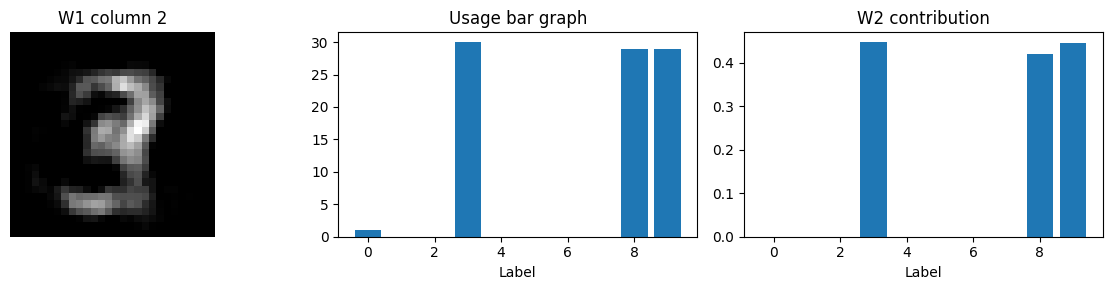

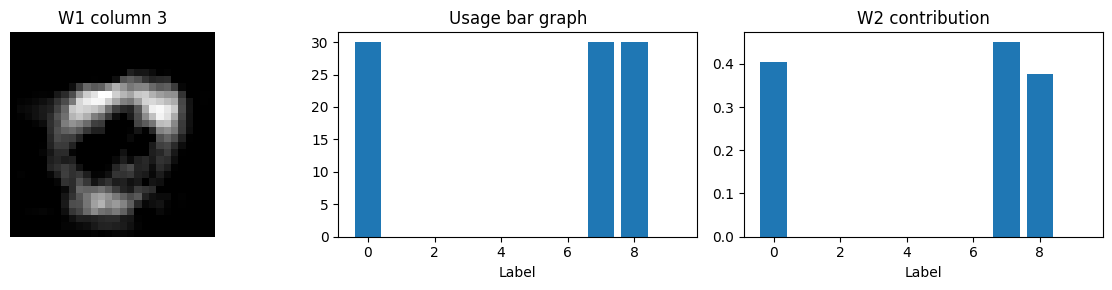

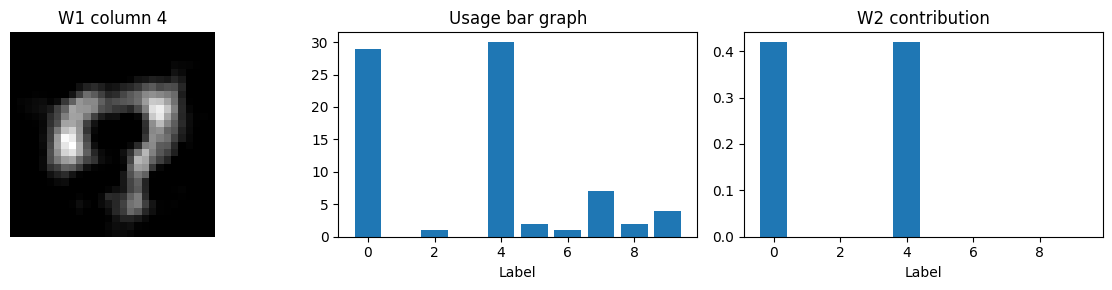

In [ ]:
print("=== W の基底可視化と使用頻度 ===")

num = 5  # 表示させる個数
feature_ids = list(range(min(k, num)))

for idx in feature_ids:
    plot_W_feature_analysis(W_final, H_final, y_train, idx)

上に示した左側の画像は、行列 $W_1$ が保持している特徴を可視化したものです。これは、学習データに現れる共通した特徴を抽出した “基底画像” に相当し、モデルはこれらを組み合わせることで元の画像を再構成できるように学習しています。

中央の棒グラフは、横軸がラベル（0〜9）、縦軸が使用回数を表しており、ある基底画像がどの数字を再構成する際にどの程度利用されたかを示しています。例えば、ラベル0の棒が20であれば、その基底画像は「0」という数字を再構成する際に 20 回利用されたことを意味します。

右側の棒グラフは、行列 $W_2$ に含まれるクラス情報の重みを可視化したものです。
$W_2$ には、対応する基底画像が「どの数字を再構成しやすい（＝どのクラスらしい特徴を持つ）」かを反映した値が学習されており、基底画像の持つクラス傾向を示す指標となります。

中央の使用回数の分布と、右側のクラス重みが概ね一致している場合、その基底画像が実際に再構成に使われた数字と、モデルがその基底画像を「どのクラスらしい」と判断している情報が一致していることになり、学習がうまく進んでいると判断できます。
基底画像の中には直感的に分かりにくいものもありますが、例えば、左の画像が「3」に見える形状をしている場合、棒グラフでもラベル3の値が高くなるなど、視覚的な印象とモデルの学習結果が整合する例も確認できました。

### $W$を用いた再構成

エポック数に対する精度と交差エントロピー誤差の比較実験の結果を用いて、学習データを再構成し、学習がどの程度うまくいっているかを$W$による再構成という観点から評価します。以下ではまず、$W$を用いて学習データを再構成し、その画像と元の学習データの画像を並べて表示する関数を作成します。

In [ ]:
def reconstruct_image_auto(W, H_test, visualize_idx):
    """
    テスト画像を、H_testの非ゼロ成分のみを用いて再構成する
    <入力>
    W：(n_features, k), 基底行列
    H_test：(k, n_test), テストデータの係数行列
    visualize_idx：(int), 対象のテストサンプルインデックス
    <出力>
    recon：(784,), 再構成された画像ベクトル（最初の784成分のみ）
    active：(array), 再構成に使用された基底のインデックス配列
    """

    active = np.where(H_test[:, visualize_idx] > 0)[0]

    h = np.zeros_like(H_test[:, visualize_idx])
    h[active] = H_test[active, visualize_idx]

    recon = W @ h

    return recon[:784], active

def show_reconstruction_auto(W, H_test, X_test, visualize_idx, y_test, y_pred):
    """
    元の画像と、選択された基底により再構成された画像を並べて表示する
    <入力>
    W：(n_features, k), 基底行列
    H_test：(k, n_test), テストデータの係数行列
    X_test：(n_test, 784), テスト画像データ
    visualize_idx：(int), 表示対象のテストサンプルインデックス
    <出力>
    なし
    """
    recon, active = reconstruct_image_auto(W, H_test, visualize_idx)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(X_test[visualize_idx].reshape(28, 28), cmap='gray')
    axes[0].set_title(f"Original\n(True: {y_test[visualize_idx]})")
    axes[0].axis("off")

    axes[1].imshow(recon.reshape(28, 28), cmap='gray')
    axes[1].set_title(f"Reconstructed\n(bases: {len(active)})\n(Pred: {y_pred[visualize_idx]})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print("Used basis columns:", active)

作成した関数を用いて再構成画像を表示します。

=== 再構成画像の表示 ===


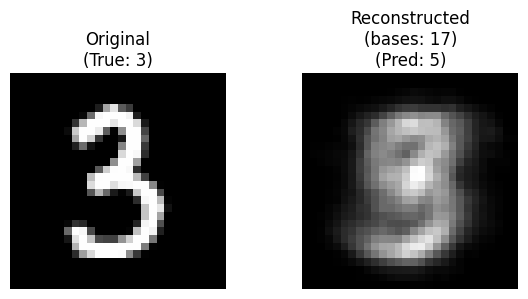

Used basis columns: [ 2  7  8  9 15 18 20 23 24 26 27 30 31 34 36 38 39]


In [ ]:
print("=== 再構成画像の表示 ===")

visualize_idx = 10  # 表示させるインデックス
show_reconstruction_auto(W_final, H_test, X_test, min(m_test-1, visualize_idx), y_test, y_pred)

異なるvisualize_idxで様々な画像を表示させると、元画像を精度よく再現している再構成画像が複数確認できます。このことから、再構成という観点からもNBMFによる学習はうまくいっていると言えます。

### 誤分類に対する分析

エポック数に対する精度と交差エントロピー誤差の比較実験の結果において、誤分類が生じてしまったサンプルの分析を行います。以下では、誤分類が生じたサンプルの画像と予測したラベルを表示する関数と、どのラベルとどのラベルで誤分類が生じたかを表す混同行列をヒートマップとして表示する関数を作成します。

In [ ]:
def show_misclassified(X_test, y_test, y_pred, num=10):
    """
    分類を間違えたテスト画像を、指定された枚数分だけ並べて表示する
    <入力>
    X_test：(n_test, 784), テスト画像データ
    y_test：(n_test,), 正解ラベル
    y_pred：(n_test,), 予測ラベル
    num：(int), 表示する画像の枚数（デフォルト10）
    <出力>
    なし
    """
    wrong = np.where(y_test != y_pred)[0]
    show_idx = wrong[:num]

    fig, axes = plt.subplots(1, len(show_idx), figsize=(1.8*len(show_idx), 2))

    if len(show_idx) == 1:
        axes = [axes]

    for ax, i in zip(axes, show_idx):
        ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
        ax.set_title(f"T={y_test[i]}, P={y_pred[i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def plot_normalized_confusion_matrix_heatmap(y_True, y_pred):
    """
    正解ラベルと予測ラベルから混同行列を作成し、
    正解ラベルごとの割合（正規化）にしてヒートマップとして表示する
    <入力>
    y_True：(n_samples,), 正解ラベル
    y_pred：(n_samples,), 予測ラベル
    <出力>
    cm_norm：(10, 10), 正規化された混同行列
    """

    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(y_True, y_pred):
        cm[t, p] += 1

    row_sums = cm.sum(axis=1, keepdims=True)

    row_sums[row_sums == 0] = 1

    cm_norm = cm / row_sums

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.colorbar()

    for i in range(10):
        for j in range(10):
            text_val = f"{cm_norm[i, j]:.2f}"

            plt.text(j, i, text_val,
                     ha='center', va='center',
                     color='white' if cm_norm[i, j] > 0.5 else 'black',
                     fontsize=9)

    plt.xticks(np.arange(10))
    plt.yticks(np.arange(10))

    plt.tight_layout()
    plt.show()

    return cm_norm

まずは、誤分類を起こしてしまった画像を表示させます。

=== 誤分類画像の表示 ===


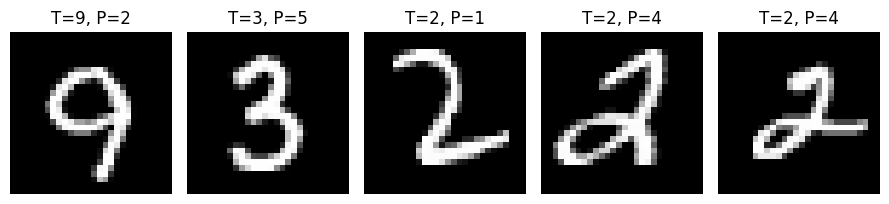

In [ ]:
print("=== 誤分類画像の表示 ===")

show_misclassified(X_test, y_test, y_pred, num=5)

続いて、混同行列をヒートマップとして表示します。



=== 混同行列の表示 ===


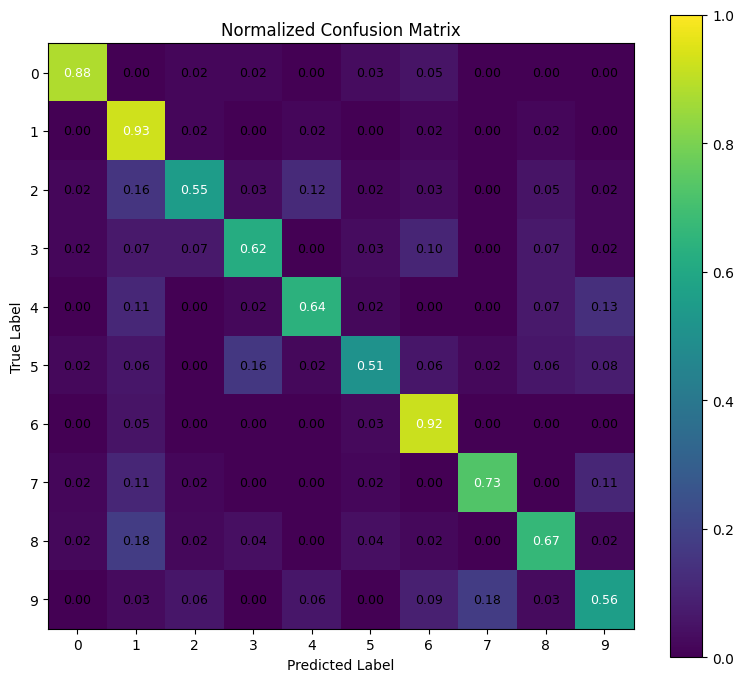

In [ ]:
print("=== 混同行列の表示 ===")

cm_norm = plot_normalized_confusion_matrix_heatmap(y_test, y_pred)

この混同行列（ヒートマップ）は、縦軸が正解ラベル、横軸が予測ラベルを表しています。したがって、対角成分の値が高いほど、その数字を正しく分類できた割合（正解率）が高いことを意味します。この混同行列の結果から、NBMFは形状がシンプルな「0」や「1」の分類を得意とする一方で、「2」「5」「9」のような複雑な形状を持つ数字の分類には課題があることが読み取れます。実際に誤分類された画像を観察すると、これらの数字は他の数字と類似した特徴を併せ持っており、それがモデルの判断を迷わせていることが確認できました。

## まとめ

本記事では、元論文の非負二値行列因子分解（NBMF）アルゴリズムを実装し、手書き数字分類タスクにおいて全結合ニューラルネットワーク（FCNN）との性能比較を行いました。 元論文と同様の条件で検証した結果、3つの実験すべてにおいて論文の報告に近い性能を再現することができました。また、学習結果の可視化を通して、モデルが数字の特徴をどのように捉えているかを視覚的に確認することができました。

## あとがき

非負二値行列因子分解（NBMF）という馴染みのなかった手法を論文から学び、それを実際に量子アニーリング（シミュレータ）で実装するという一連のプロセスは非常に勉強になりました。今後は、誤分類が多かった複雑な数字に対する認識精度の向上や、実機のアニーリングマシンを用いた検証にも挑戦してみたいと思います。